# Fake Job Posting Detection using NLP and Linear SVM
This project builds an NLP-based fraud detection system to classify job postings as legitimate or fraudulent.  
TF-IDF is used for text representation, and multiple machine learning models are evaluated, including Logistic Regression and Linear SVM.  
The final model is selected based on the balance between precision and recall for fraudulent job detection.

##  Problem Statement
Online job platforms are vulnerable to fraudulent job postings, which can mislead applicants and damage platform trust.  
The objective of this project is to build a machine learning model that can identify fake job postings using textual information from job ads.

##  Business Objective
In this problem, false negatives are particularly important because missing a fraudulent job posting means allowing a scam listing to remain undetected.  
At the same time, excessive false positives are also undesirable because they may wrongly flag legitimate employers.  
Therefore, the project focuses on finding a strong balance between recall and precision.

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("fake_job_postings.csv")

# Check basic structure
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


##  Dataset Overview
The dataset contains job postings labeled as either legitimate or fraudulent.  
It includes multiple text-based fields such as title, company profile, description, requirements, and benefits, along with the target variable `fraudulent`.

In [2]:
# Shape od dataset
df.shape

(17880, 18)

In [3]:
# Data types + missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

### Dataset Summary

The dataset contains 17,880 rows and 18 columns.  
The target variable is highly imbalanced, with legitimate postings making up the majority of the data and fraudulent postings representing only a small fraction.  
This class imbalance makes accuracy an unreliable metric on its own.

In [4]:
# Check target distribiution
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [5]:
# Percentage distribution
df['fraudulent'].value_counts(normalize=True)

fraudulent
0    0.951566
1    0.048434
Name: proportion, dtype: float64

##  Data Preparation

To prepare the text data for modeling, missing values in the selected text columns were replaced with empty strings and multiple text fields were merged into a single combined text feature.  
This ensures that all relevant textual information is captured in one representation for downstream NLP processing.

In [6]:
# Fill missing values with empty string
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

for col in text_columns:
    df[col] = df[col].fillna('')

# Combine into one column
df['combined_text'] = (
    df['title'] + ' ' +
    df['company_profile'] + ' ' +
    df['description'] + ' ' +
    df['requirements'] + ' ' +
    df['benefits']
)

# Check result
df[['combined_text']].head()

,combined_text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC Our passion ...
4,Bill Review Manager SpotSource Solutions LLC i...


### Text Cleaning
The combined text was cleaned by converting all characters to lowercase, removing punctuation and numbers, and normalizing extra spaces.  
This step reduces noise and ensures a more consistent vocabulary for TF-IDF vectorization.

In [7]:
import re

def clean_text(text):
    # Lowercase
    text = text.lower()

     # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning
df['cleaned_text'] = df['combined_text'].apply(clean_text)

# Check results
df[['combined_text', 'cleaned_text']].head()

,combined_text,cleaned_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern were food and weve created a ...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc our passion fo...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc i...


### Cleaning Summary

Basic text cleaning was applied to standardize the corpus before feature extraction.  
This helps reduce duplicate tokens caused by inconsistent formatting and improves the quality of the TF-IDF representation.

# NOTE This TF-IDF transformation was done on the full dataset only to understand the feature matrix shape.
 It is not used for final modeling because fitting on all data before splitting causes data leakage.

## TF-IDF Feature Engineering
Since machine learning models cannot work directly with raw text, TF-IDF vectorization was used to transform textual content into numerical features.  
This representation highlights words that are important in a document while reducing the influence of overly common words.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,   # limit features
    stop_words='english' # remove common words like 'the', 'is'
)

# Transform text into numeric features
X = tfidf.fit_transform(df['cleaned_text'])

# Target variable
y = df['fraudulent']

# Check shape
X.shape

(17880, 5000)

### Feature Engineering Summary

The text data was transformed into a high-dimensional sparse matrix using TF-IDF.  
This representation is especially suitable for linear models such as Logistic Regression and Linear SVM.

##  Train-Test Split
The dataset was split into training and test sets using stratification to preserve the original class distribution.  
TF-IDF was fitted only on the training data to prevent data leakage.

In [9]:
from sklearn.model_selection import train_test_split

# Split raw cleaned text and target first
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['fraudulent'],
    test_size=0.2,
    random_state=42,
    stratify=df['fraudulent']
)

# Check split sizes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14304,)
X_test shape: (3576,)
y_train shape: (14304,)
y_test shape: (3576,)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit TF-IDF only on training text
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Check TF-IDF shapes
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (14304, 5000)
X_test_tfidf shape: (3576, 5000)


## Baseline Model: Logistic Regression

Logistic Regression requires numerical features and benefits from scaling, but in TF-IDF-based text data, features are already normalized, so additional scaling is not required. Class imbalance is handled using class_weight.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train baseline Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.968400447427293

Confusion Matrix:
 [[3310   93]
 [  20  153]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.62      0.88      0.73       173

    accuracy                           0.97      3576
   macro avg       0.81      0.93      0.86      3576
weighted avg       0.98      0.97      0.97      3576



### Logistic Regression - Summary & Insights

The Logistic Regression model achieved an overall accuracy of approximately 96.8%, but due to the imbalanced nature of the dataset, accuracy alone is not a reliable metric.

The model demonstrated strong performance in detecting fraudulent job postings, achieving a recall of 88% for the minority class (fake jobs). This indicates that the model successfully identifies most fraudulent listings, which is critical in a real-world fraud detection system where missing fraudulent cases can have serious consequences.

However, the model shows a relatively lower precision of 62% for fake jobs, meaning that a significant number of legitimate job postings are incorrectly classified as fraudulent (false positives). While this trade-off is somewhat acceptable in fraud detection scenarios, improving precision without sacrificing recall would enhance the model’s practical usability.

### Transition to Support Vector Machines (SVM)

Although Logistic Regression provides a strong baseline, it is fundamentally a linear model that may struggle to fully capture complex patterns in high-dimensional text data.

Support Vector Machines (SVM), particularly Linear SVM, are -ell-suited for:

- High-dimensional and sparse data (such as TF-IDF features)
- Maximizing the margin between classes, which often leads to better generalization
- Handling imbalanced data effectively with proper regularization

Therefore, the next step is to evaluate whether SVM can improve the balance between precision and recall, especially for detecting fraudulent job postings.

### Linear SVM (Support Vector Machine)
Linear SVM was selected as the primary model because TF-IDF produces high-dimensional sparse features, which are well suited to linear margin-based classifiers.  
The model was evaluated to determine whether it could improve the precision-recall balance compared with Logistic Regression.

In [12]:
from sklearn.svm import LinearSVC

# Train SVM
svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Accuracy: 0.9829418344519015

Confusion Matrix:
 [[3372   31]
 [  30  143]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.82      0.83      0.82       173

    accuracy                           0.98      3576
   macro avg       0.91      0.91      0.91      3576
weighted avg       0.98      0.98      0.98      3576



### Model Comparison: Logistic Regression vs SVM

Both Logistic Regression and Linear SVM performed well on the dataset, but they exhibit different trade-offs.

Logistic Regression achieved higher recall for fraudulent job postings (88%), meaning it successfully detected more fake jobs and minimized false negatives. This is critical in fraud detection scenarios where missing fraudulent cases can have serious consequences.

On the other hand, Linear SVM significantly improved precision for the fraudulent class (82% vs 62%), reducing the number of false positives and making it more reliable in flagging suspicious jobs.

However, SVM showed a slight decrease in recall (83%), indicating that it missed more fraudulent postings compared to Logistic Regression.

Overall, Logistic Regression is more suitable when the priority is to detect as many fraudulent job postings as possible, while SVM is preferable when reducing false alarms is more important.

## Improving the Linear SVM Model

The initial Linear SVM model delivered strong results, particularly in terms of precision for fraudulent job detection. However, further improvement may be possible by tuning both the text representation and the model hyperparameters.

Since text classification performance is heavily influenced by feature extraction, the next step is to optimize the TF-IDF configuration alongside the Linear SVM parameter `C` using a pipeline and grid search.

###  Full Grid Search
To improve model performance, the TF-IDF configuration and SVM regularization parameter were tuned using a pipeline and grid search.  
This ensures that preprocessing and model selection are optimized together in a leakage-safe workflow.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

# Build pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svm', LinearSVC(class_weight='balanced', random_state=42, dual='auto'))
])

# Define parameter grid
param_grid = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [2, 5],
    'tfidf__max_df': [0.8, 0.9],
    'svm__C': [0.1, 1, 5]
}

# Grid search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit on training text
grid_search.fit(X_train, y_train)

# Best results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

In [14]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

[[3376   27]
 [  38  135]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.83      0.78      0.81       173

    accuracy                           0.98      3576
   macro avg       0.91      0.89      0.90      3576
weighted avg       0.98      0.98      0.98      3576



After the full grid search produced a model with weaker recall, a second controlled experiment was conducted using smaller values of C while keeping the best-performing TF-IDF settings fixed.  
This was done to recover recall without sacrificing too much precision.

###  Controlled Tuning

In [15]:
# Controlled pipeline
pipeline_recall = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.8
    )),
    ('svm', LinearSVC(class_weight='balanced', random_state=42, dual='auto'))
])

# Smaller C values
param_grid_recall = {
    'svm__C': [0.01, 0.05, 0.1, 0.5, 1]
}

# Grid search
grid_recall = GridSearchCV(
    estimator=pipeline_recall,
    param_grid=param_grid_recall,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_recall.fit(X_train, y_train)

print("Best Parameters:", grid_recall.best_params_)
print("Best Cross-Validation F1 Score:", grid_recall.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'svm__C': 1}
Best Cross-Validation F1 Score: 0.7575228799589794


In [16]:
best_model_recall = grid_recall.best_estimator_

y_pred_recall = best_model_recall.predict(X_test)

print(confusion_matrix(y_test, y_pred_recall))
print(classification_report(y_test, y_pred_recall))

[[3371   32]
 [  27  146]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.82      0.84      0.83       173

    accuracy                           0.98      3576
   macro avg       0.91      0.92      0.91      3576
weighted avg       0.98      0.98      0.98      3576



##  Final Model Comparison
This table summarizes the performance of all evaluated models using the key business-relevant metrics for fraudulent job detection.

In [17]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

def get_metrics(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_Fake': precision_score(y_true, y_pred, pos_label=1),
        'Recall_Fake': recall_score(y_true, y_pred, pos_label=1),
        'F1_Fake': f1_score(y_true, y_pred, pos_label=1),
        'False_Positive': fp,
        'False_Negative': fn
    }

results = [
    get_metrics("Logistic Regression", y_test, y_pred_lr),
    get_metrics("Original Linear SVM", y_test, y_pred_svm),
    get_metrics("Tuned SVM (full grid, C=5)", y_test, y_pred_tuned),
    get_metrics("Controlled SVM tuning (best C=1)", y_test, y_pred_recall)
]

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision_Fake,Recall_Fake,F1_Fake,False_Positive,False_Negative
0,Logistic Regression,0.968400,0.621951,0.884393,0.730310,93,20
1,Original Linear SVM,0.982942,0.821839,0.826590,0.824207,31,30
2,"Tuned SVM (full grid, C=5)",0.981823,0.833333,0.780347,0.805970,27,38
3,Controlled SVM tuning (best C=1),0.983501,0.820225,0.843931,0.831909,32,27


## Final Model Selection

After evaluating multiple models, including Logistic Regression, the baseline Linear SVM, and two tuned SVM configurations, the Controlled SVM model with C = 1 was selected as the final model.

While Logistic Regression achieved the highest recall for detecting fraudulent job postings, it produced a large number of false positives, making it less practical for real-world deployment.

The original Linear SVM provided a strong balance between precision and recall, but further tuning revealed that a slightly lower regularization strength (C = 1) improved recall while maintaining precision.

The final Controlled SVM model achieved the highest F1-score, indicating the best balance between precision and recall. It also reduced false negatives compared to the baseline SVM, making it more effective at detecting fraudulent job postings without significantly increasing false alarms.

Therefore, the Controlled SVM model was selected as the most suitable model for this problem.

##  ROC-AUC Analysis
ROC-AUC was used to evaluate the model’s ranking ability across all possible decision thresholds.  
Unlike precision and recall at a single threshold, ROC-AUC shows how well the model separates fraudulent and legitimate postings overall.

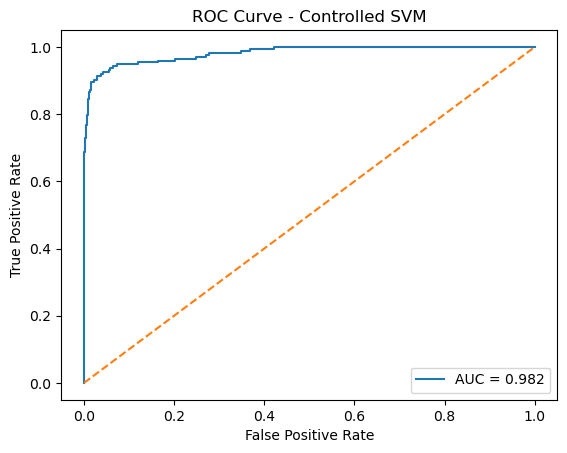

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get decision scores (NOT probabilities)
y_scores = best_model_recall.decision_function(X_test)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Controlled SVM')
plt.legend()
plt.show()

### ROC-AUC Summary

The model achieved a strong ROC-AUC score, indicating excellent class separability.  
This suggests that the model is capable of distinguishing fake and legitimate job postings effectively across a range of thresholds.

## Threshold Analysis
Because fraud detection often depends on business priorities, threshold analysis was performed to study the trade-off between recall and precision.  
Lower thresholds increase fraud detection but also increase false alarms, while higher thresholds reduce false alarms but miss more fraud.

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Get decision scores
y_scores = best_model_recall.decision_function(X_test)

# Define thresholds to test
thresholds = np.arange(-1.0, 1.1, 0.2)

results = []

for t in thresholds:
    y_pred = (y_scores > t).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    results.append({
        'Threshold': round(t, 2),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'False_Positive': fp,
        'False_Negative': fn
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Precision,Recall,F1,False_Positive,False_Negative
0,-1.0,0.190205,0.965318,0.317793,711,6
1,-0.8,0.302026,0.947977,0.458101,379,9
2,-0.6,0.440217,0.936416,0.598891,206,11
3,-0.4,0.564286,0.913295,0.697572,122,15
4,-0.2,0.731132,0.895954,0.805195,57,18
5,-0.0,0.820225,0.843931,0.831909,32,27
6,0.2,0.850000,0.786127,0.816817,24,37
7,0.4,0.901408,0.739884,0.812698,14,45
8,0.6,0.967213,0.682081,0.800000,4,55
9,0.8,0.973451,0.635838,0.769231,3,63


## Model Interpretation
To improve interpretability, the most influential TF-IDF features learned by the final Linear SVM model were examined.  
This helps identify the language patterns associated with fraudulent and legitimate job postings.

In [19]:
import numpy as np

# Get feature names
feature_names = best_model_recall.named_steps['tfidf'].get_feature_names_out()

# Get SVM weights 
coefficients = best_model_recall.named_steps['svm'].coef_[0]

# Top positive (fake job indicators)
top_positive_idx = np.argsort(coefficients)[-20:]

# Top negative (real job indicators)
top_negative_idx = np.argsort(coefficients)[:20]

print("Top words indicating FAKE jobs:\n")
for i in reversed(top_positive_idx):
    print(feature_names[i])

print("\nTop words indicating REAL jobs:\n")
for i in top_negative_idx:
    print(feature_names[i])

Top words indicating FAKE jobs:

aptitude
high school
word
sales executive
type
networking
assisting
beverage
money
ohio
oriented
receptionist
oil gas
accountant
sites
apply
earning
subsea
offshore
financing

Top words indicating REAL jobs:

companies
english
fun
hardware
team
university
exceptional
helps
based
procurement
handling
consultants
installation
digital
sign
software
expected
leaders
distribution
affordable


### Interpretation Summary
The model associates fraudulent postings with vague, promotional, and money-oriented language, while legitimate postings are linked to more structured, technical, and role-specific terms.  
This suggests that the classifier is learning meaningful linguistic signals rather than relying on random noise.

## Limitations and Future Improvements
Although the final model performed strongly, several limitations remain.  
The model relies primarily on textual information and does not yet incorporate additional metadata features that may improve fraud detection.  
The extracted important words are also model-indicative rather than definitive proof of fraud.

Future improvements could include:
- incorporating structured metadata features
- experimenting with other models such as XGBoost or transformer-based NLP models
- calibrating or optimizing thresholds based on business cost
- deploying the final model in an interactive application